In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('data_science_job.csv')

In [4]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [5]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [6]:
df.shape

(19158, 13)

In [10]:
cols=[var for var in df.columns if df[var].isnull().mean()<0.05 and df[var].isnull().mean()>0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [13]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
17840,NaN,Full time course,Graduate,1.0,3.0
18736,0.855,no_enrollment,Graduate,0.0,41.0
15721,0.920,no_enrollment,NaN,10.0,20.0
8263,0.788,no_enrollment,Graduate,20.0,6.0
18128,0.910,no_enrollment,Graduate,20.0,178.0


In [14]:
len(df[cols].dropna())/len(df)

0.8968577095730244

In [17]:
new_df=df[cols].dropna()
df.shape,new_df.shape

((19158, 13), (17182, 5))

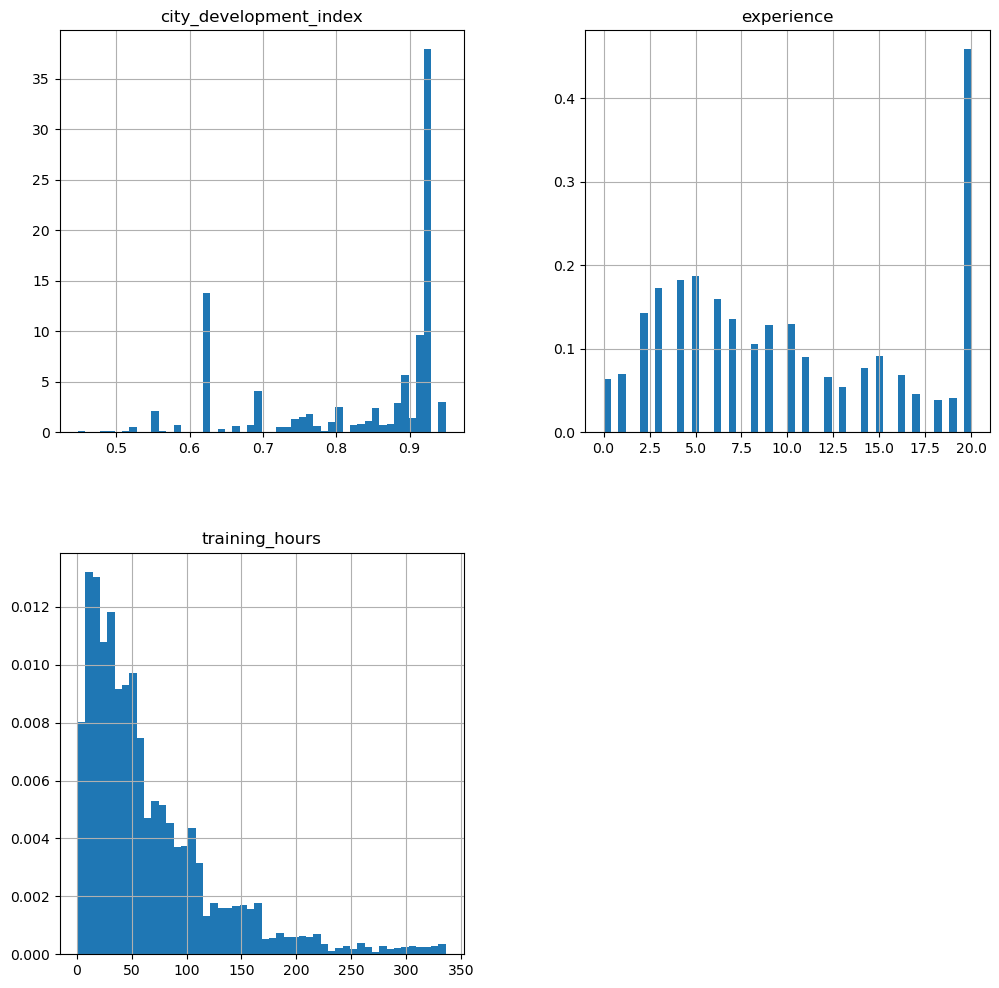

In [21]:
new_df.hist(bins=50,density=True,figsize=(12,12))
plt.show()

<Axes: >

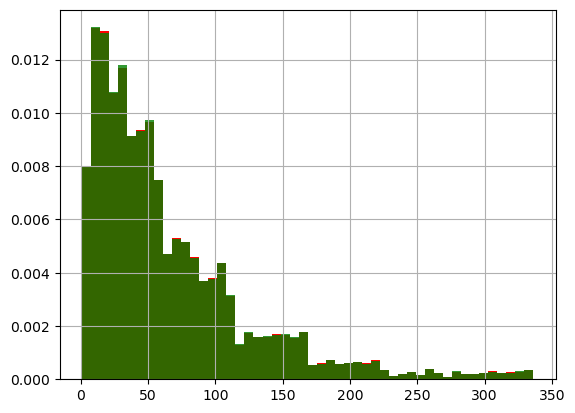

In [23]:
fig=plt.figure()
ax=fig.add_subplot(111)
# orginal data
df['training_hours'].hist(bins=50,ax=ax,density=True,color='red')
# after CCA
# see ovelay of the distrubution
new_df['training_hours'].hist(bins=50,ax=ax,color='green',density=True,alpha=0.8)

<Axes: ylabel='Density'>

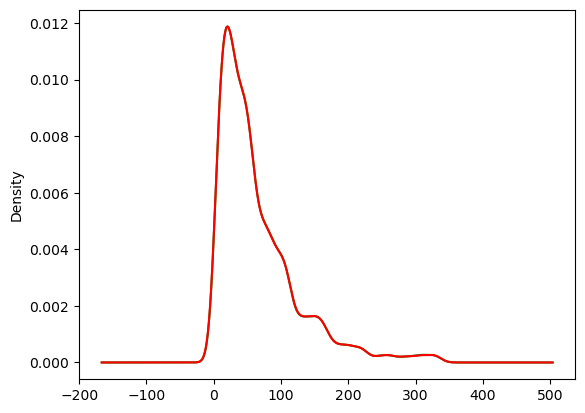

In [25]:
fig=plt.figure()
ax=fig.add_subplot(111)
#before Orignal data
df['training_hours'].plot.density(color='green')
#After CCA
new_df['training_hours'].plot.density(color='red')

<Axes: >

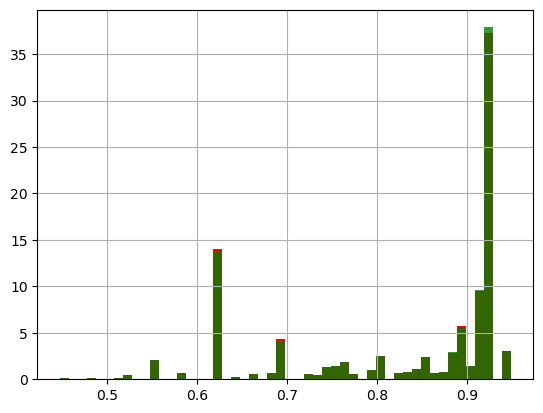

In [27]:
fig=plt.figure()
ax=fig.add_subplot(111)
df['city_development_index'].hist(bins=50,ax=ax,density=True,color='red')
# after CCA
new_df['city_development_index'].hist(bins=50,ax=ax,density=True,color='green',alpha=0.8)

<Axes: ylabel='Density'>

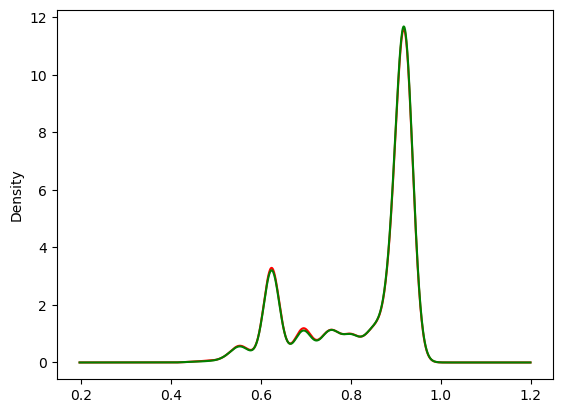

In [28]:
fig=plt.figure()
ax=fig.add_subplot(111)
df['city_development_index'].plot.density(color='red')
# after CCA
new_df['city_development_index'].plot.density(color='green')

<Axes: ylabel='Density'>

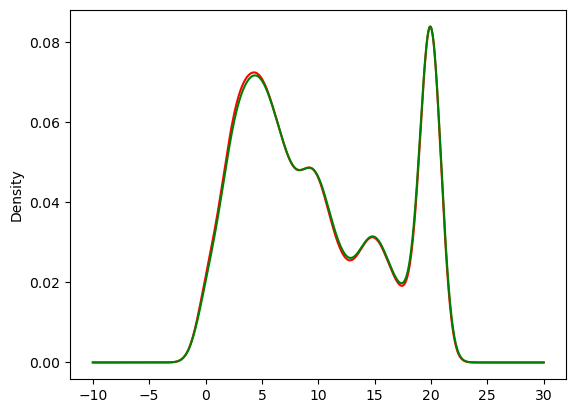

In [29]:
fig=plt.figure()
ax=fig.add_subplot(111)
df['experience'].plot.density(color='red')
# after CCA
new_df['experience'].plot.density(color='green')

In [30]:
df['enrolled_university'].value_counts()

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64

In [35]:
temp=pd.concat([
    df['enrolled_university'].value_counts()/len(df),
    new_df['enrolled_university'].value_counts()/len(new_df)
],axis=1)

temp.columns=['orignal','cca']

print(temp)

                      orignal       cca
enrolled_university                    
no_enrollment        0.721213  0.735188
Full time course     0.196106  0.200733
Part time course     0.062533  0.064079


In [ ]:
temp=pd.concat([
    df['education_level'].value_counts()/len(df),
    new_df['education_level'].value_counts()/len(new_df)
],axis=1)

temp.columns=['orignal','cca']

print(temp)